# Decision Trees

*Notebook Overview*
- Decision Tree for the Models
We fit several decision tree classifiers to predict whether a match occurs:
    - Model A uses demographic variables only
    - Model B uses demographic variables + participants' stated dating preferences before the event
    - Model C uses post-date scorecard ratings, capturing how participants actually felt after interacting 
- Permutation Importance
- Partial Importance Plots

In [3]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

In [4]:
dating = pd.read_csv(
    "Speed Dating Data.csv",
    encoding="latin1", 
    header=0,
    skiprows=[1]
)

dating.head()
dating.columns

Index(['iid', 'id', 'gender', 'idg', 'condtn', 'wave', 'round', 'position',
       'positin1', 'order',
       ...
       'attr3_3', 'sinc3_3', 'intel3_3', 'fun3_3', 'amb3_3', 'attr5_3',
       'sinc5_3', 'intel5_3', 'fun5_3', 'amb5_3'],
      dtype='object', length=195)

Variable Additions 

- Model C requires additional variables that we need to add

In [5]:
# 1. SELECT COLUMNS
columns_to_keep = [
    'iid', 'id', 'idg', 'wave',
    'match',
    'gender',
    'age',
    'age_o',
    'race',
    'race_o',
    'attr1_1',
    'sinc1_1',
    'intel1_1',
    'fun1_1',
    'amb1_1',
    'shar1_1',
    'pf_o_att',
    'pf_o_sin',
    'pf_o_int',
    'pf_o_fun',
    'pf_o_amb',
    'pf_o_sha', 
    'attr', #add variables for model C
    'sinc', 'intel', 'fun', 'amb', 'shar', 'attr_o', 'sinc_o','intel_o','fun_o','amb_o','shar_o']

dating = dating[columns_to_keep].copy()



# 2. FILTER FOR WAVE 1–5
dating = dating[dating['wave'].between(1, 5)]
print(f"Shape after wave filtering (1-5): {dating.shape}")

 
# 3. EDA COPY (FULL sample: gender 0 + 1)
dating_full = dating.copy()  


# 4. MISSING VALUES REPORT (ONLY REPORT)
print("\nMissing values in each column (EDA view):")
print(dating_full.isna().sum())

 
# 5. MODELING DATASET
# Apply gender = 0 and drop missing vals
dating_model = dating_full[
    dating_full['gender'] == 0
].dropna().copy()

print(f"\nShape of modeling dataset (gender=0, dropna): {dating_model.shape}")

print("\nDataset info for modeling:")
dating_model.info()

Shape after wave filtering (1-5): (1845, 34)

Missing values in each column (EDA view):
iid           0
id            0
idg           0
wave          0
match         0
gender        0
age          30
age_o        39
race         20
race_o       30
attr1_1      36
sinc1_1      36
intel1_1     36
fun1_1       46
amb1_1       56
shar1_1      56
pf_o_att     46
pf_o_sin     46
pf_o_int     46
pf_o_fun     55
pf_o_amb     64
pf_o_sha     64
attr         26
sinc         43
intel        42
fun          68
amb         132
shar        221
attr_o       36
sinc_o       53
intel_o      52
fun_o        78
amb_o       142
shar_o      230
dtype: int64

Shape of modeling dataset (gender=0, dropna): (633, 34)

Dataset info for modeling:
<class 'pandas.core.frame.DataFrame'>
Index: 633 entries, 0 to 1744
Data columns (total 34 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   iid       633 non-null    int64  
 1   id        633 non-null    float64
 2   idg     

# Decision tree - Model A (Demographics Only)

Predictors include:
- Participant age
- Participant race

- Partner age
- Partner race

In [6]:
# Model A: Demographics

X_A = dating_model[['age', 'age_o', 'race', 'race_o']]
y = dating_model['match']

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y, test_size=0.25, random_state=42, stratify=y
)

dt_A = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

dt_A.fit(X_train_A, y_train_A)

y_pred_A = dt_A.predict(X_test_A)
y_prob_A = dt_A.predict_proba(X_test_A)[:, 1]

print("Model A — Decision Tree")
print("Accuracy:", accuracy_score(y_test_A, y_pred_A))
print("ROC AUC:", roc_auc_score(y_test_A, y_prob_A))
print(classification_report(y_test_A, y_pred_A))

Model A — Decision Tree
Accuracy: 0.7987421383647799
ROC AUC: 0.562007874015748
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       127
           1       0.00      0.00      0.00        32

    accuracy                           0.80       159
   macro avg       0.40      0.50      0.44       159
weighted avg       0.64      0.80      0.71       159



c:\Users\Cecilia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Cecilia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Cecilia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
np.unique(y_pred_A, return_counts=True)


(array([0], dtype=int64), array([159], dtype=int64))

# Decision Tree Visualization: Model A 

We'll now visualize the fitted decision tree to see whether demographic variables create decision rules that separate matches from non-matches. 

Model A, which used only demographic variables (age and race of participant and partner), achieved relatively high accuracy due to class imbalance but failed to identify any matches. The model predicted all observations as non-matches, resulting in zero recall for the match class and a ROC AUC only slightly above chance. This suggests that demographic variables alone are insufficient for predicting mutual attraction, motivating the inclusion of preference-based ratings in subsequent models.

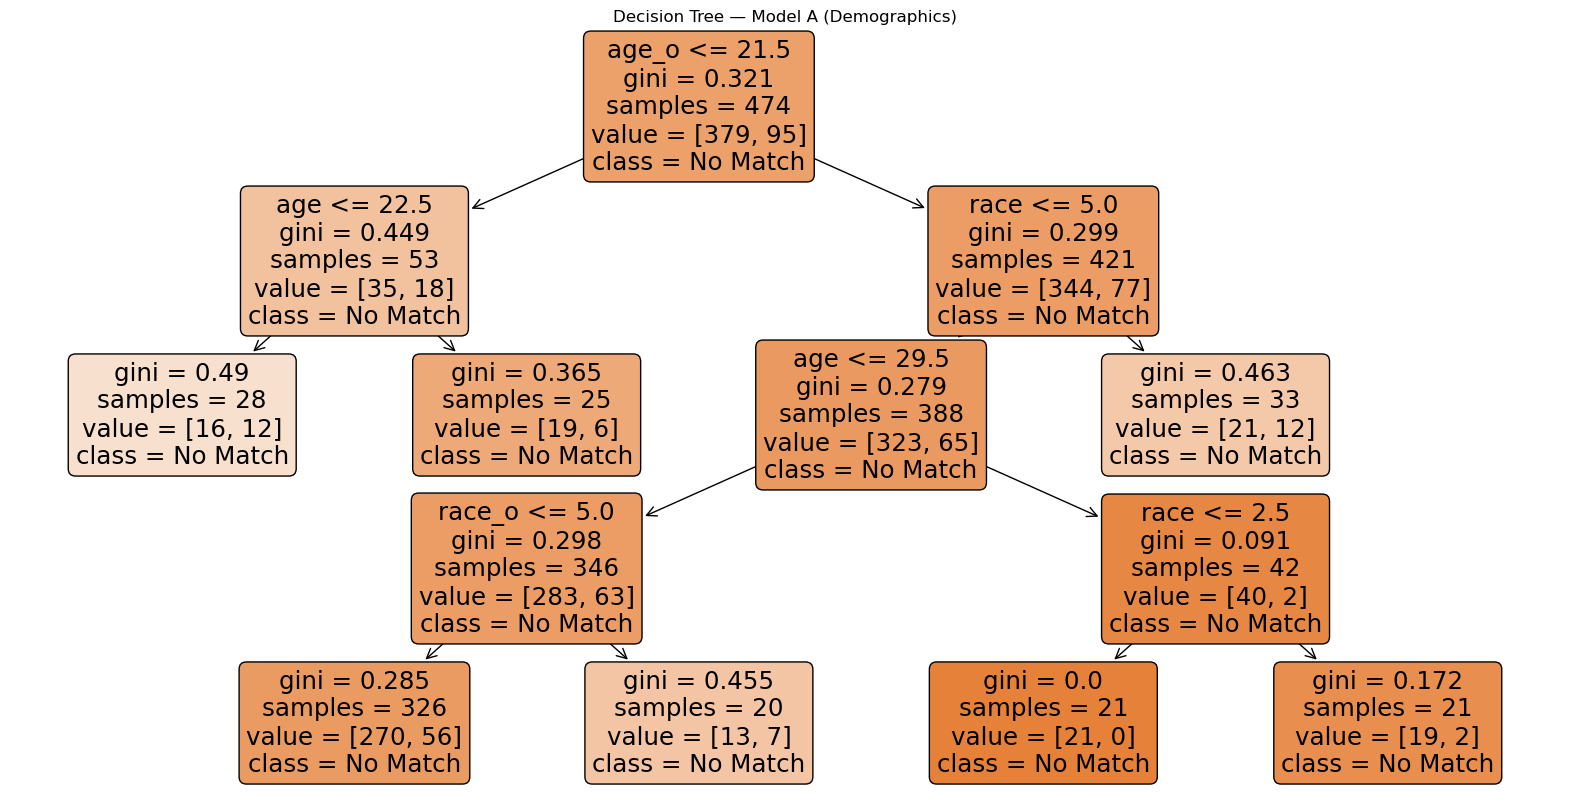

In [8]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_A,
    feature_names=X_A.columns,
    class_names=['No Match', 'Match'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree — Model A (Demographics)")
plt.show()

# Decision Tree Model B: Dating Theories, Metacognition, and Match Outcomes

Model B examines whether participants’ self-reported dating theories (what they think they value in dating)align with their actual romantic decision-making during the speed-dating event. Specifically, this model investigates the role of metacognition, whether individuals’ beliefs about what they value in a partner correspond to the choices they actually make. 

Predictors include:
- Participants’ stated importance of attributes such as attractiveness, sincerity, intelligence, fun, ambition, and shared interests, 
- Their partners’ reported importance of the same attributes. 

By incorporating both perspectives, this model tests whether particular combinations of expressed preferences are predictive of real match outcomes. If dating decisions closely follow stated theories, we would expect these self-reported values to meaningfully distinguish matches from non-matches. Conversely, weak predictive power would suggest a gap between participants’ perceived decision strategies and their actual behavior (what they think they value is different from their actual decisions).

In [9]:
# Model B: Dating Theory Weights

X_B = dating_model[
    [
        'attr1_1',
        'sinc1_1',
        'intel1_1',
        'fun1_1',
        'amb1_1',
        'shar1_1',
        'pf_o_att',
        'pf_o_sin',
        'pf_o_int',
        'pf_o_fun',
        'pf_o_amb',
        'pf_o_sha'
    ]
]

y = dating_model['match']

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y, test_size=0.25, random_state=42, stratify=y
)

dt_B = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

dt_B.fit(X_train_B, y_train_B)

y_pred_B = dt_B.predict(X_test_B)
y_prob_B = dt_B.predict_proba(X_test_B)[:, 1]

print("Model B — Decision Tree")
print("Accuracy:", accuracy_score(y_test_B, y_pred_B))
print("ROC AUC:", roc_auc_score(y_test_B, y_prob_B))
print(classification_report(y_test_B, y_pred_B))

Model B — Decision Tree
Accuracy: 0.7861635220125787
ROC AUC: 0.5954724409448818
              precision    recall  f1-score   support

           0       0.80      0.97      0.88       127
           1       0.33      0.06      0.11        32

    accuracy                           0.79       159
   macro avg       0.57      0.52      0.49       159
weighted avg       0.71      0.79      0.72       159



# Decision Tree Visualization: Model B

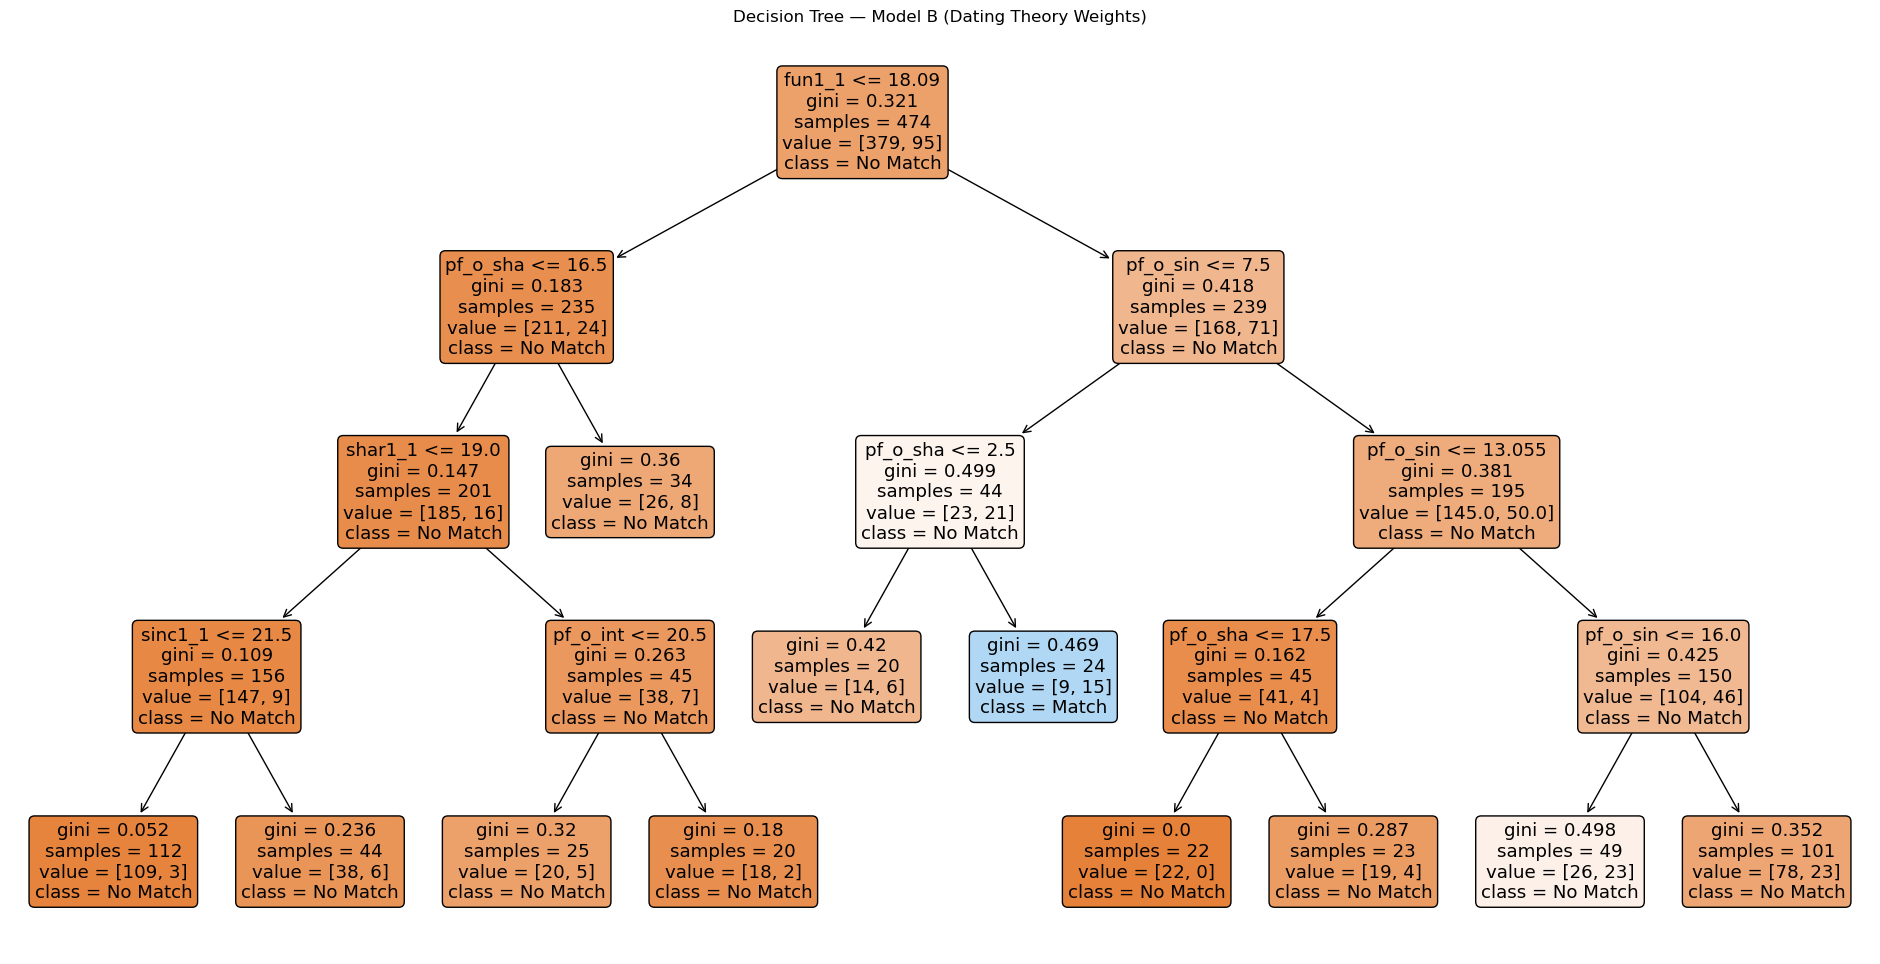

In [10]:
plt.figure(figsize=(24, 12))
plot_tree(
    dt_B,
    feature_names=X_B.columns,
    class_names=['No Match', 'Match'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree — Model B (Dating Theory Weights)")
plt.show()

# Decision Tree Model C: Post-Date Scorecard Ratings

This model focuses on evaluations made after the speed-dating interactions, capturing participants’ immediate impressions of their partners rather than their stated theories or expectations. 

Predictors include:
- Both participant and partner ratings of key attributes such as attractiveness, fun, sincerity, intelligence, ambition, and shared interests
- Basic demographic variables included for context. 

By using post-date scorecard ratings, this model tests whether lived experience during the interaction is more predictive of match outcomes than pre-event preferences or self-reported dating theories. In doing so, it allows us to examine whether matches are better explained by how individuals actually perceive one another in the moment, potentially revealing consistent patterns in decision-making that differ from what participants believe guides their choices.

In [11]:
# Model C: Post-Date scorecard Ratings

X_C = dating_model[
    [
        'age',
        'age_o',
        'race',
        'race_o',
        'attr',
        'sinc',
        'intel',
        'fun',
        'amb',
        'shar',
        'attr_o',
        'sinc_o',
        'intel_o',
        'fun_o',
        'amb_o',
        'shar_o'
    ]
]

y = dating_model['match']

X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(
    X_C, y, test_size=0.25, random_state=42, stratify=y
)

dt_C = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

dt_C.fit(X_train_C, y_train_C)

y_pred_C = dt_C.predict(X_test_C)
y_prob_C = dt_C.predict_proba(X_test_C)[:, 1]

print("Model C — Decision Tree")
print("Accuracy:", accuracy_score(y_test_C, y_pred_C))
print("ROC AUC:", roc_auc_score(y_test_C, y_prob_C))
print(classification_report(y_test_C, y_pred_C))

Model C — Decision Tree
Accuracy: 0.8113207547169812
ROC AUC: 0.7346210629921259
              precision    recall  f1-score   support

           0       0.82      0.98      0.89       127
           1       0.62      0.16      0.25        32

    accuracy                           0.81       159
   macro avg       0.72      0.57      0.57       159
weighted avg       0.78      0.81      0.76       159



# Decision Tree Visualization: Model C

There is some uncertainty, but this model shows stronger separation between matches and non-matches.

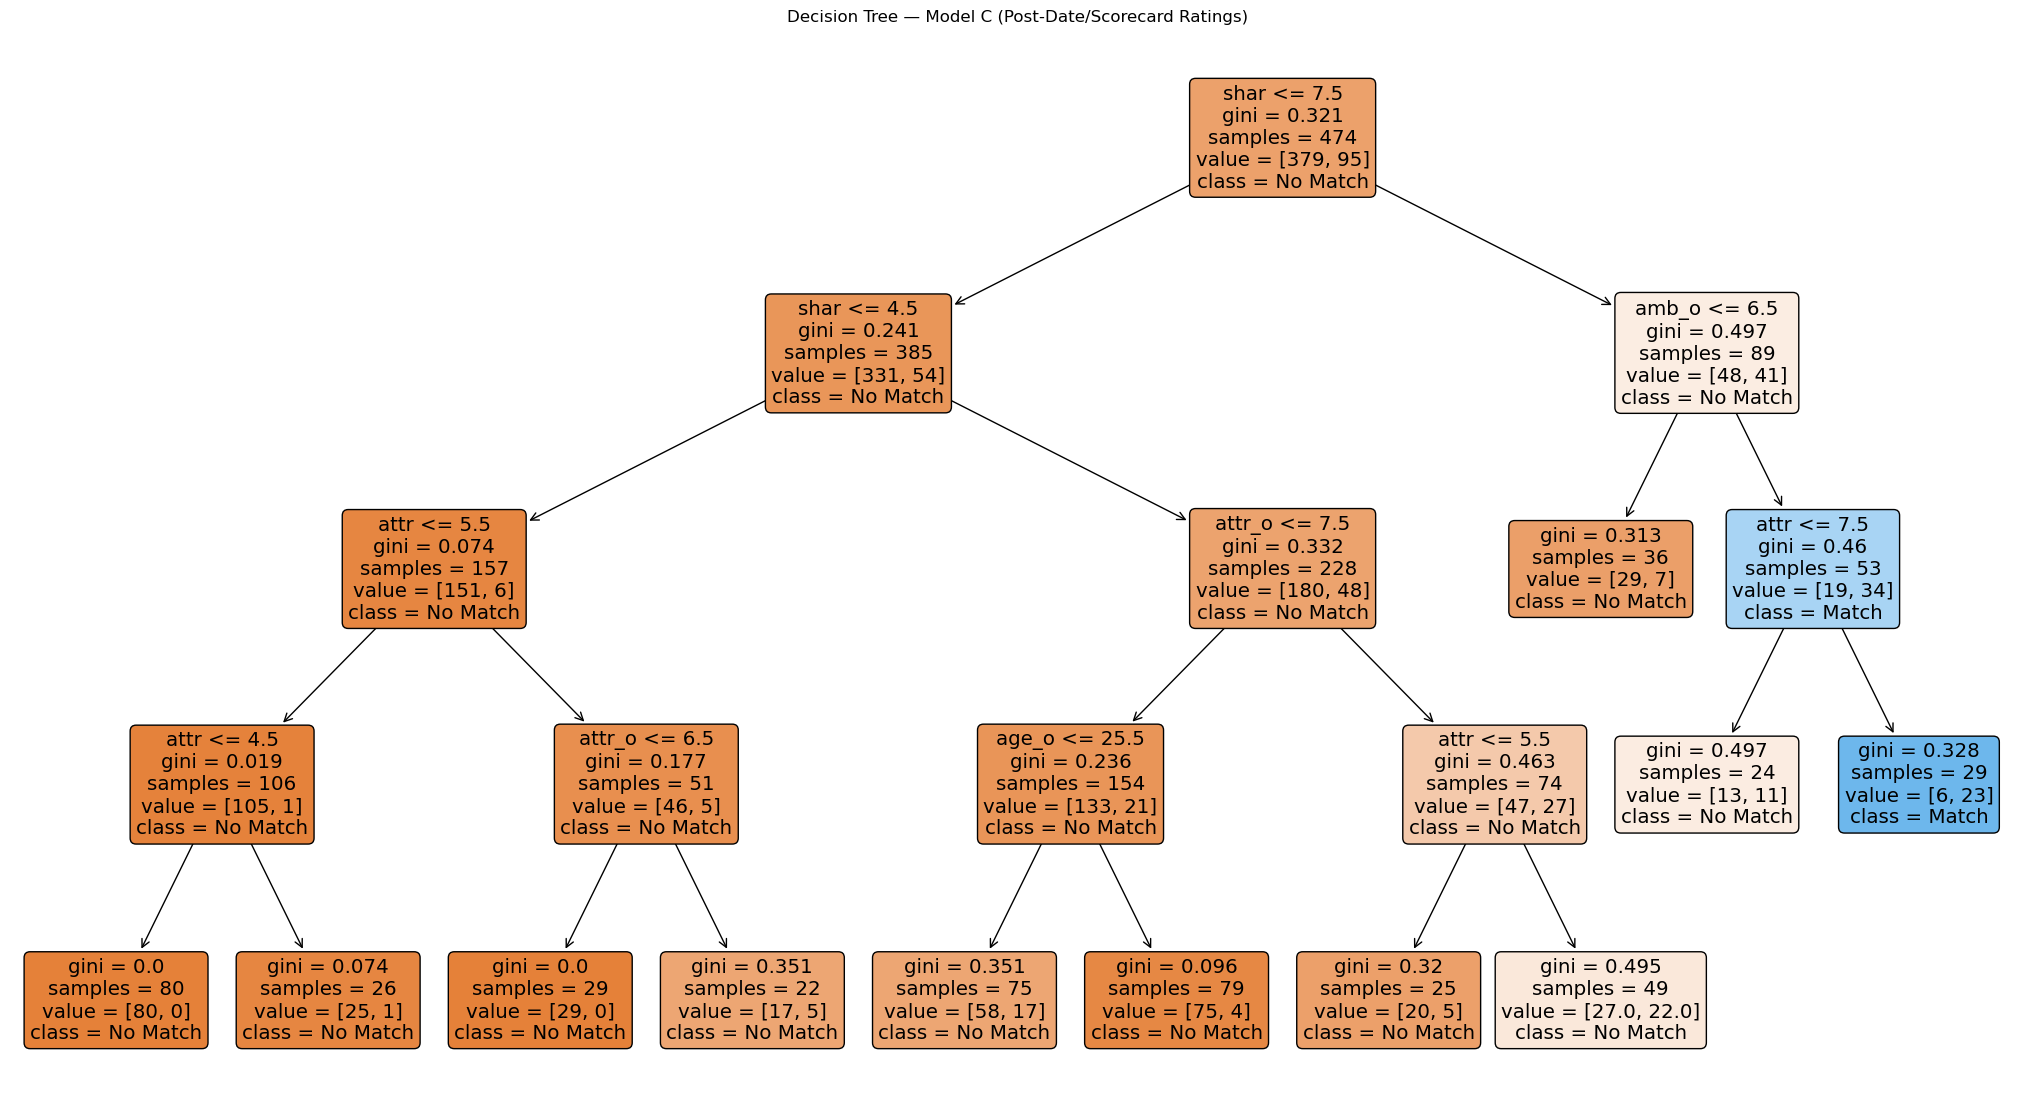

In [12]:
plt.figure(figsize=(26, 14))
plot_tree(
    dt_C,
    feature_names=X_C.columns,
    class_names=['No Match', 'Match'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree — Model C (Post-Date/Scorecard Ratings)")
plt.show()

# Permutation Importance: Model C

Now we will use permutation importance to see which variables are most important for predictive factor. 

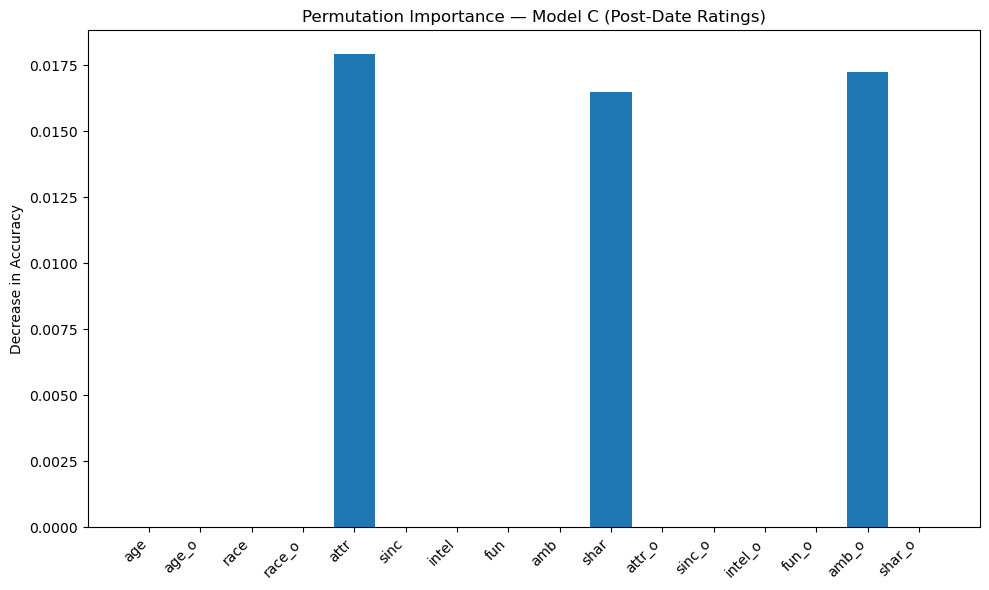

In [13]:
result_C = permutation_importance(
    dt_C,
    X_test_C,
    y_test_C,
    n_repeats=100
)

plt.figure(figsize=(10, 6))
plt.bar(X_test_C.columns, result_C['importances_mean'])
plt.xticks(rotation=45, ha='right')
plt.title('Permutation Importance — Model C (Post-Date Ratings)')
plt.ylabel('Decrease in Accuracy')
plt.tight_layout()
plt.show()

The results reveal that post-date perceptions of attractiveness and fun are the most influential predictors of a successful match. 

Next we're going to apply partial dependence of the variables that were revealed to be important from permutation importance: attr, shar, and amb_o. This will show how changing this variable affects the probability of a match.

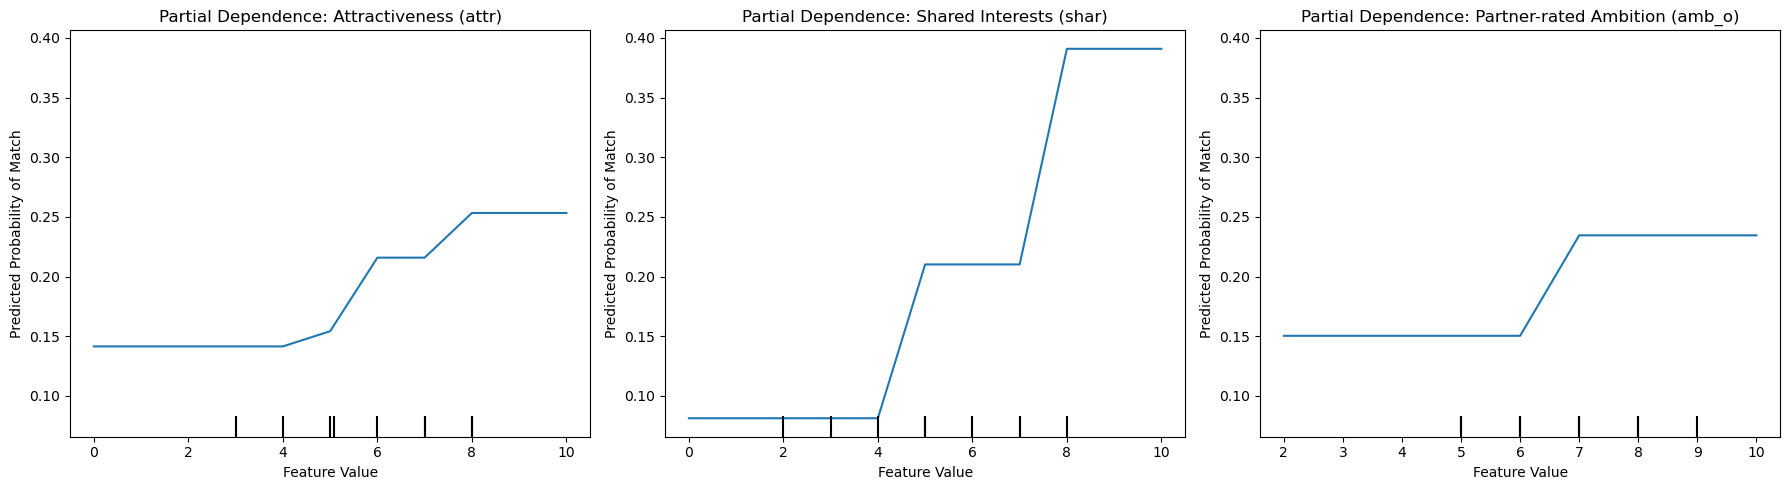

In [14]:
features_of_interest = ['attr', 'shar', 'amb_o']

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

PartialDependenceDisplay.from_estimator(
    dt_C,
    X_train_C,
    features=features_of_interest,
    ax=ax,
    kind='average'
)

ax[0].set_title("Partial Dependence: Attractiveness (attr)")
ax[1].set_title("Partial Dependence: Shared Interests (shar)")
ax[2].set_title("Partial Dependence: Partner-rated Ambition (amb_o)")

for a in ax:
    a.set_ylabel("Predicted Probability of Match")
    a.set_xlabel("Feature Value")

plt.tight_layout()
plt.show()

#Interpretations

Attractiveness (attr)
- As attractiveness ratings increase, the probability of a match steadily increases.
- The increase is gradual rather than sudden, suggesting attractiveness consistently helps but is not an all-or-nothing factor.
- Very high attractiveness scores correspond to the highest predicted match probabilities, but the effect levels off slightly at the top.
Being perceived as more attractive generally improves match chances, but it works as part of a broader combination of traits rather than guaranteeing a match on its own.

Shared Interests (shar)
- Match probability stays relatively low at lower shared-interest ratings.
- Once shared interests reach a higher threshold, the predicted probability of a match jumps sharply.
- This suggests shared interests may act as a deciding factor rather than a gradual influence.
Shared interests seem to matter most once they reach a certain level — when people feel they really “click,” match likelihood increases dramatically.

Partner-Rated Ambition (amb_o)
- Match probability remains fairly flat at lower ambition ratings.
- When partner-rated ambition increases, match probability rises and then stabilizes.
- This indicates ambition is valued, but only up to a point.
Being perceived as ambitious helps, but once someone is seen as “ambitious enough,” additional ambition doesn’t significantly change match outcomes.

Taken together, these partial dependence plots suggest that what people experience during the date matters more than what they say they value beforehand. Physical attraction contributes steadily, shared interests can be a turning point that pushes interactions into “match” territory, and ambition helps as long as it meets expectations. Rather than one single trait determining success, matches seem to emerge when multiple positive impressions line up at the right levels.